## Analyse the slideseqV2 and slidetag dataset.

### slideseqV2 datasets

In [1]:
import sys
sys.path.insert(0, '/home/zhouwg/data1/project/Garfield')

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/data1/anaconda3/envs/env_garfield/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.0.1'

In [3]:
# Load data
# Enable optimized spatial graph construction (5-20x speedup for large datasets)
os.environ['GARFIELD_USE_OPTIMIZED_GRAPH'] = '1'

dataset='slideseqv2'
file_fold = '/home/zhouwg/data1/project/Garfield_review/data'
adata = sc.read_h5ad(file_fold + '/slideseqv2_mouse_hippocampus.h5ad')
adata.var_names_make_unique()

In [4]:
adata

AnnData object with n_obs × n_vars = 41786 × 4000
    obs: 'cell_type', 'batch'
    obsm: 'spatial'
    layers: 'counts'

In [5]:
adata.obs['cell_type'].value_counts()

cell_type
CA1_CA2_CA3_Subiculum       7649
DentatePyramids             6606
Astrocytes                  6543
Interneurons                3672
Oligodendrocytes            3602
Subiculum_Entorhinal_cl2    2896
Endothelial_Stalk           1991
Subiculum_Entorhinal_cl3    1985
Polydendrocytes             1449
Endothelial_Tip             1317
Microglia                   1298
Mural                       1027
Neurogenesis                 938
Ependymal                    813
Name: count, dtype: int64

In [6]:
# Ensure adata.X is counts.
# adata.layers['counts'] = adata.X.copy()
adata.X = adata.layers['counts'].copy()
adata.X.max()

169.0

### Integrating spatially resolved transcriptomics data using Garfield

In [7]:
# set workdir #
workdir = '/home/zhouwg/data1/project/Garfield_review/Results/sp_unimodal/spRNA_slideseqv2'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=adata,
    profile='spatial',
    data_type='single-modal',
    sample_col=None,
    weight=0.5,
    ## Preprocessing options
    graph_const_method='mu_std', # mu_std, Radius, KNN, Squidpy
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=False,
    adj_key='connectivities',
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,
    ## Model options
    augment_type='dropout',
    svd_q=5,
    use_FCencoder=True,
    conv_type='GCN', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    num_workers=4,  # Increase for async data loading (e.g., 2-4)
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1.0,
    lambda_edge_recon=10.0,
    lambda_latent_adj_recon_loss=0.,
    lambda_omics_recon_mmd_loss=0.2,
    # train parameters
    n_epochs=100,
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # Single-GPU configuration (NEW Lightning parameters)
    accelerator='gpu',
    devices=[1],          # Use 1 GPU
    strategy='auto',  # auto mode for single-gpu
    precision='32',     # '32', '16-mixed', or 'bf16-mixed'
    # Logging and checkpointing
    logger='tensorboard',  # 'tensorboard', 'csv', or None
    log_every_n_steps=50,
    checkpoint_dir=None,  # Defaults to workdir/checkpoints
    save_top_k=1,
    save_last=True,
    # Other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    seed=2024,
    use_lightning=True,
    log_style='auto',
    verbose=True,
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /home/zhouwg/data1/project/Garfield_review/Results/sp_unimodal/spRNA_slideseqv2


In [8]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Using optimized graph construction...
------Calculating spatial graph (model=mu_std)...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [9]:
# Train model
model.train()

Seed set to 2024
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
You are using a CUDA device ('NVIDIA A800-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



--- Using PyTorch Lightning Trainer (Distributed Training) ---
Initializing PyTorch Lightning components...

--- DATA PREPARATION (Lightning DataModule) ---


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Number of training nodes: 37607
Number of validation nodes: 4179
Number of training edges: 214281
Number of validation edges: 23809
Edge batch size: 4096
Node batch size: 128


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GNNModelVAE │  1.3 M │ train │     0 │
└───┴───────┴─────────────┴────────┴───────┴───────┘

...

Epoch 48/100 |█████████-----------| 48.0% lr-AdamW: 0.0010; train_kl_reg_loss: 78.7896; train_kl_reg_loss_step: 76.8334; train_edge_recon_loss: 9061.7051; train_edge_recon_loss_step: 2894.2246; train_gene_expr_recon_loss: 5102.5400; train_gene_expr_recon_loss_step: 5078.4517; train_lambda_latent_adj_recon_loss: 0.0000; train_lambda_latent_adj_recon_loss_step: 0.0000; train_lambda_latent_contrastive_instanceloss: 7.8715; train_lambda_latent_contrastive_instanceloss_step: 7.8954; train_lambda_latent_contrastive_clusterloss: 2.1956; train_lambda_latent_contrastive_clusterloss_step: 2.2514; train_global_loss: 14253.1025; train_global_loss_step: 8059.6567; train_optim_loss: 14253.1025; train_optim_loss_step: 8059.6567; val_kl_reg_loss: 82.2153; val_edge_recon_loss: 8661.3506; val_gene_expr_recon_loss: 4692.0640; val_lambda_latent_adj_recon_loss: 0.0000; val_lambda_latent_contrastive_instanceloss: 7.8390; val_lambda_latent_contrastive_clusterloss: 2.4378; val_global_loss: 13445.9062; val_opt

Epoch 47, global step 2544: 'val_global_loss' was not in top 1


Epoch 49/100 |█████████-----------| 49.0% lr-AdamW: 0.0010; train_kl_reg_loss: 78.6930; train_kl_reg_loss_step: 75.3940; train_edge_recon_loss: 9053.2910; train_edge_recon_loss_step: 2903.9531; train_gene_expr_recon_loss: 5084.1826; train_gene_expr_recon_loss_step: 5101.1611; train_lambda_latent_adj_recon_loss: 0.0000; train_lambda_latent_adj_recon_loss_step: 0.0000; train_lambda_latent_contrastive_instanceloss: 7.8783; train_lambda_latent_contrastive_instanceloss_step: 7.8864; train_lambda_latent_contrastive_clusterloss: 2.2056; train_lambda_latent_contrastive_clusterloss_step: 2.1676; train_global_loss: 14226.2510; train_global_loss_step: 8090.5620; train_optim_loss: 14226.2510; train_optim_loss_step: 8090.5620; val_kl_reg_loss: 82.0258; val_edge_recon_loss: 8671.1279; val_gene_expr_recon_loss: 4671.4131; val_lambda_latent_adj_recon_loss: 0.0000; val_lambda_latent_contrastive_instanceloss: 7.8225; val_lambda_latent_contrastive_clusterloss: 2.4179; val_global_loss: 13434.8066; val_opt

Monitored metric val_global_loss did not improve in the last 8 records. Best score: 13421.774. Signaling Trainer to stop.
Epoch 48, global step 2597: 'val_global_loss' was not in top 1




Loading best model from /data1/TianLab/zhouwg/project/Garfield_review/Results/sp_unimodal/spRNA_slideseqv2/checkpoints/garfield-epoch=40-val_global_loss=13421.7744.ckpt

--- MODEL EVALUATION ---
val AUROC score: 0.9348
val AUPRC score: 0.9243
val best accuracy score: 0.8637
val best F1 score: 0.8707
val MSE score: 0.2342

--- COMPUTING LATENT EMBEDDINGS ---
Embeddings stored in adata.obsm['garfield_latent']


In [10]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [11]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.5
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

12

/home/zhouwg/data1/anaconda3/envs/env_garfield/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


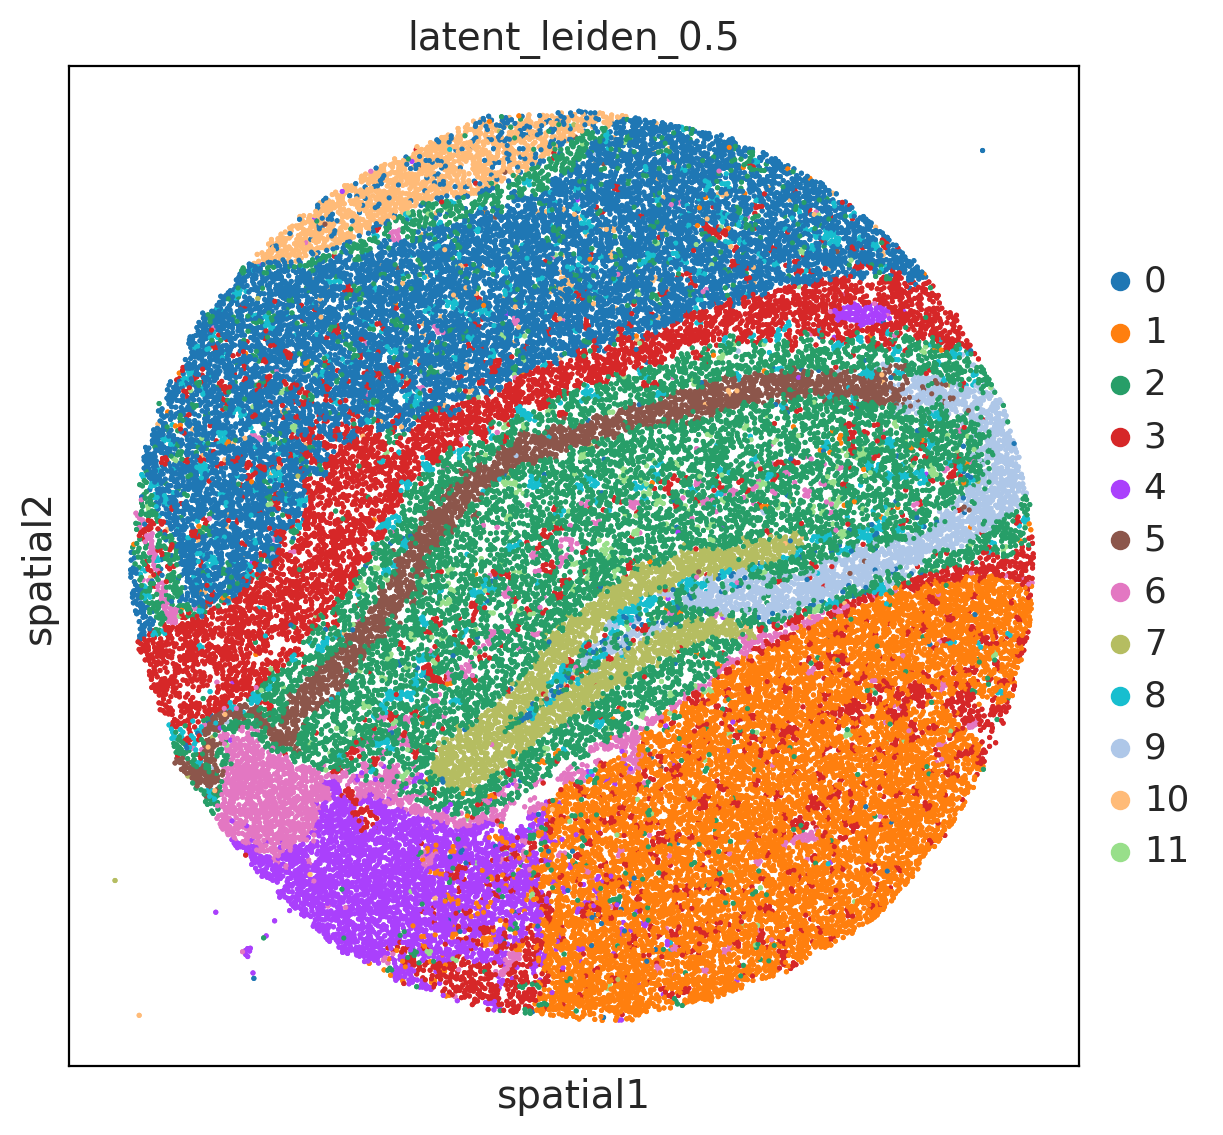

In [12]:
import squidpy as sq
sc.settings.set_figure_params(dpi=100, facecolor='white')

sq.pl.spatial_scatter(model.adata, color=latent_cluster_key, shape=None, figsize=(6, 6))

### Visualize Garfield Latent Space

In [ ]:
import squidpy as sq

sq.pl.spatial_scatter(model.adata, color=latent_cluster_key, shape=None, figsize=(12, 12))

In [ ]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [ ]:
# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

import matplotlib.pyplot as plt
# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正
sc.pl.embedding(model.adata, basis='spatial', color=latent_cluster_key,
                title='Garfield Niches', s=10, show=False)
# plt.gca().invert_yaxis()  # 翻转 y 轴
# plt.show()
# pic(os.path.join(workdir, "01.spatial_plot_niche.pdf"))

In [ ]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

adata_batch = model.adata#[model.adata.obs['batch'] == batch].copy()
sc.pl.umap(adata_batch, color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3)

cluster_list = list(adata_batch.obs[latent_cluster_key].unique()) # ['0', '1', '3']
highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    2, math.ceil(len(cluster_list) / 2), figsize=(2 * len(cluster_list), 8)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[int(cluster)]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[int(cluster)], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"Niche {cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
# plt.show()
# pic(os.path.join(workdir, "03.spatial_plot_each_niche.pdf"))

In [ ]:
## niche 注释
cluster2annotation = {
    '0': 'CL', #
    '1': 'LP', #
    '2': 'Stratum', #
    '3': 'Corpus_callosum', #
    '4': 'MH&LH', #
    '5': 'Stria_medullaris',
    '6': 'CA1', #
    '7': 'DG', #
    '8': 'Stratum', #
    '9': 'CA2&CA3', #
    '10': 'V3' #
}
model.adata.obs['niche_type'] = model.adata.obs[latent_cluster_key].map(cluster2annotation).astype('category')

In [ ]:
## 改变 categories的顺序
print(model.adata.obs['niche_type'].cat.categories)
new_order = ['CL','LP','Stratum', 'Corpus_callosum', 'MH&LH',
             'Stria_medullaris', 'CA1', 'DG', 'CA2&CA3', 'V3']
model.adata.obs['niche_type'] = pd.Categorical(model.adata.obs['niche_type'],
                                               categories=new_order, ordered=True)

In [ ]:
# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.umap(model.adata, color='niche_type', ax=ax_list[0], title='Garfield Niches',
           s=10, show=False,legend_loc=None)
sc.pl.embedding(model.adata, basis='spatial', color='niche_type', ax=ax_list[1],
                title='Garfield Niches', s=10, show=False)
# plt.gca().invert_yaxis()  # 翻转 y 轴
plt.tight_layout(w_pad=0.3)
# plt.show()
pic(os.path.join(workdir, "02.spatial_plot_niche_concat.pdf"))

In [ ]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

adata_batch = model.adata#[model.adata.obs['batch'] == batch].copy()
latent_cluster_key = 'niche_type'

cluster_list = ['CA1', 'CA2&CA3', 'DG', 'V3', 'MH&LH']
highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    1, len(cluster_list), figsize=(20, 4.5)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    cluster_index = cluster_list.index(cluster)
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[cluster_index]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[cluster_index], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"{cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
pic(os.path.join(workdir, "03.spatial_plot_each_niche.pdf"))

In [ ]:
gene_list = ['Wfs1', 'Cpne4', 'C1ql2', 'Enpp2', 'Nwd2']
fig, ax_list = plt.subplots(1, len(gene_list), figsize=(20, 4))

for gene, ax in zip(gene_list, ax_list):
    sc.pl.embedding(model.adata, basis='spatial', color=gene,
                    ax=ax, show=False, color_map='YlOrRd', s=10)

plt.tight_layout(w_pad=0.3)
plt.show()
pic(os.path.join(workdir, "04.spatial_plot_each_niche_marker.pdf"))

In [ ]:
ditto_color=[
            "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
            "#D55E00", "#CC79A7", "#666666", "#AD7700", "#1C91D4",
            "#007756", "#D5C711", "#005685", "#A04700", "#B14380",
            "#4D4D4D", "#FFBE2D", "#80C7EF", "#00F6B3", "#F4EB71",
            "#06A5FF", "#FF8320", "#D99BBD", "#8C8C8C"
        ]

sc.pl.umap(model.adata, color='cell_type', title='Garfield',
           s=10, show=False,palette=ditto_color)
# plt.close()

In [ ]:
# scanpy结果画细胞分类百分比例图
import os
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# 数据处理
df = model.adata.obs[['niche_type', 'cell_type']].groupby(["niche_type", "cell_type"]).size().unstack(fill_value=0)
labels = df.index.tolist()  # 提取分类标签
results = df.to_dict(orient="list")  # 将数值结果转化为字典
category_names = list(results.keys())  # 提取类别（键-key）
data = np.array(list(results.values()))  # 提取数值（值-value）
category_colors = model.adata.uns["cell_type_colors"]  # 分类颜色

# 计算相似性并进行层次聚类
data_normalized = data / data.sum(axis=0)  # 正规化百分比
dist_matrix = squareform(pdist(data_normalized.T, metric="euclidean"))  # 计算样本之间的欧式距离
linkage_matrix = linkage(dist_matrix, method="ward")  # 使用层次聚类方法
dendro = dendrogram(linkage_matrix, labels=labels, no_plot=True)  # 获取聚类树的顺序

# 按聚类结果重新排序
ordered_labels = [labels[i] for i in dendro['leaves']]
ordered_data = data_normalized[:, dendro['leaves']]

# 创建主图和聚类树
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# 绘制聚类树
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    labels=ordered_labels,
    orientation="top",
    leaf_rotation=90,
    ax=ax_dendro,
    color_threshold=0,
)
ax_dendro.axis("off")  # 隐藏聚类树的坐标轴

# 绘制柱状图
ax_bar = fig.add_subplot(gs[1, 0])
starts = np.zeros(len(ordered_labels))  # 基准为 0

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    heights = ordered_data[i, :]  # 使用聚类排序后的数据
    ax_bar.bar(
        ordered_labels,
        heights,
        bottom=starts,
        width=0.5,
        label=colname,
        color=color,
        edgecolor="gray",
    )
    starts += heights  # 基于基准累加

# 美化柱状图
ax_bar.tick_params(axis="x", length=0)
ax_bar.set_xlabel("Niches", fontsize=12)
ax_bar.set_ylabel("Proportion", fontsize=12)
ax_bar.set_ylim(0, 1.01)
ax_bar.set_yticks(np.arange(0, 1.2, 0.2))
ax_bar.set_yticklabels([f"{int(i * 100)}%" for i in np.arange(0, 1.2, 0.2)])
ax_bar.grid(axis="y", alpha=0.5, ls="--")

# 添加图例，将图例移至图外
plt.legend(title='CellType', bbox_to_anchor=(1.05, 1), loc='upper left')

# 保存和展示
plt.tight_layout()
# plt.savefig(os.path.join(workdir, "05.barplot_niche.pdf"), dpi=600)
pic(os.path.join(workdir, "05.barplot_niche.pdf"))

In [ ]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

In [ ]:
# Save trained model
model_folder_path = f"{workdir}/model_vali"
os.makedirs(model_folder_path, exist_ok=True)

model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref_vali.h5ad")

In [ ]:
from Garfield.model import Garfield

workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2'
gf.settings.set_workdir(workdir)
model_folder_path = f"{workdir}/model"

model = Garfield.load(dir_path=model_folder_path,
              adata_file_name="adata_ref.h5ad")

## Garfield

In [ ]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

In [ ]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import pandas as pd
from mudata import MuData
import time

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

### 2.1 Define Training Function

In [ ]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal/'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal"

In [ ]:
model_name = "garfield"
latent_key = f"{model_name}_latent"

In [ ]:
def train_garfield_models(dataset,
                         cell_type_key,
                         niche_type_key=None,
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # Load trained SCVI results
        dataset='slideseqv2'
        root_dir = '/pri_exthome/zhouwg/project/spatial_data'
        file_fold = os.path.join(root_dir, str(dataset))
        adata = sc.read_h5ad(file_fold + '/slideseqv2.h5ad')
        adata.var_names_make_unique()

        # Store raw counts in adata.layers
        adata.layers["counts"] = sp.csr_matrix(np.round((np.exp(adata.X.toarray()) - 1)))
        adata.X = adata.layers['counts'].copy()

        ### modify parameter
        user_config = dict(
            ## Input options
            adata_list=adata,
            profile='spatial',
            data_type='single-modal',
            sample_col=None,
            weight=0.5,
            ## Preprocessing options
            graph_const_method='Squidpy', # mu_std, Radius, KNN, Squidpy
            used_hvg=True,
            min_cells=3,
            min_features=0,
            keep_mt=False,
            target_sum=1e4,
            rna_n_top_features=3000,
            n_components=50,
            n_neighbors=n_neighbors,
            metric='euclidean',
            svd_solver='arpack',
            # datasets
            used_pca_feat=False,
            adj_key='connectivities',
            # data split parameters
            edge_val_ratio=0.1,
            edge_test_ratio=0.,
            node_val_ratio=0.1,
            node_test_ratio=0.,
            ## Model options
            augment_type='dropout',
            svd_q=5,
            use_FCencoder=True,
            conv_type='GAT', # GAT or GATv2Conv or GCN
            gnn_layer=2,
            hidden_dims=[128, 128],
            bottle_neck_neurons=20,
            cluster_num=20,
            drop_feature_rate=0.2,
            drop_edge_rate=0.2,
            num_heads=3,
            dropout=0.2,
            concat=True,
            used_edge_weight=False,
            used_DSBN=False,
            used_mmd=False,
            # data loader parameters
            num_neighbors=5,
            loaders_n_hops=2,
            edge_batch_size=4096,
            node_batch_size=256, # None
            # loss parameters
            include_edge_recon_loss=True,
            include_gene_expr_recon_loss=True,
            lambda_latent_contrastive_instanceloss=1.0,
            lambda_latent_contrastive_clusterloss=0.5,
            lambda_gene_expr_recon=1., #
            lambda_edge_recon=1., #
            lambda_latent_adj_recon_loss=2.,
            lambda_omics_recon_mmd_loss=0.2,
            # train parameters
            n_epochs_no_edge_recon=0,
            learning_rate=0.001,
            weight_decay=1e-05,
            gradient_clipping=5,
            # other parameters
            latent_key='garfield_latent',
            reload_best_model=True,
            use_early_stopping=True,
            early_stopping_kwargs=None,
            monitor=True,
            device_id=1,
            seed=2024,
            verbose=True
        )
        dict_config = gf.settings.set_gf_params(user_config)

        from Garfield.model import Garfield
        # Initialize model
        model = Garfield(dict_config)

        start_time = time.time()

        # Train model
        model.train()

        # Compute latent neighbor graph
        # sc.pp.neighbors(model.adata,
        #                 use_rep=latent_key,
        #                 key_added=latent_key)
        #
        # # Compute UMAP embedding
        # sc.tl.umap(model.adata,
        #            neighbors_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = model.adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

In [ ]:
train_garfield_models(dataset="adata_slideseqv2",
                         cell_type_key="cell_type",
                         niche_type_key="niche_type",
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

In [ ]:
root_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_unimodal'
adata = sc.read_h5ad(root_dir + '/slideseqv2_garfield.h5ad')
adata

In [ ]:
# Compute latent neighbor graph
latent_key = 'garfield_latent_run8'
sc.pp.neighbors(adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(adata,
           neighbors_key=latent_key)

In [ ]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.5
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"

sc.tl.leiden(adata=adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(adata.obs[latent_cluster_key].unique())

In [ ]:
import squidpy as sq
sc.settings.set_figure_params(dpi=100, facecolor='white')

sq.pl.spatial_scatter(adata, color=latent_cluster_key, shape=None, figsize=(6, 6))

## slidetag datasets

In [ ]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

In [ ]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

In [ ]:
# read data
import scipy.sparse as sp

dataset='slidetag'
root_dir = '/pri_exthome/zhouwg/project/spatial_data'
file_fold = os.path.join(root_dir, str(dataset))
adata = sc.read_h5ad(file_fold + '/SCP2162.h5ad')
adata.var_names_make_unique()

# Create new adata to drop all unnecessary columns
adata_new = sc.AnnData(sp.csr_matrix(
    (adata.shape[0], adata.shape[1]),
    dtype=np.float32))
adata_new.X = adata.X
adata_new.var_names = adata.var_names
adata_new.obs_names = adata.obs_names
adata_new.obsm["spatial"] = adata.obsm["spatial"]
adata_new.obs["cell_type"] = adata.obs["cluster"].values

# Store raw counts in adata.layers
adata_new.layers["counts"] = sp.csr_matrix(np.round((np.exp(adata.X) - 1)))
adata_new

In [ ]:
# Ensure adata.X is counts.
# adata.layers['counts'] = adata.X.copy()
adata_new.X = adata_new.layers['counts'].copy()
adata_new.X.max()

### Integrating spatially resolved transcriptomics data using Garfield

In [ ]:
# set workdir #
workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_SCP2162'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=adata_new,
    profile='spatial',
    data_type='single-modal',
    sample_col=None,
    weight=0.5,
    ## Preprocessing options
    graph_const_method='mu_std', # mu_std, Radius, KNN, Squidpy
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=False,
    adj_key='connectivities',
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,
    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False,
    conv_type='GAT', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=5., #
    lambda_edge_recon=1., #
    lambda_latent_adj_recon_loss=2.,
    lambda_omics_recon_mmd_loss=0.2,
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=0,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

In [ ]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

In [ ]:
# Train model
model.train()

In [ ]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [ ]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.3
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

### Visualize Garfield Latent Space

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

sc.pl.umap(model.adata, color='cell_type', title='Garfield',
           s=10, show=False) # , legend_loc='on data'

In [ ]:
import squidpy as sq

sq.pl.spatial_scatter(model.adata, color=latent_cluster_key, shape=None, figsize=(6, 6))

In [ ]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [ ]:
model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

import matplotlib.pyplot as plt
# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正
sc.pl.embedding(model.adata, basis='spatial', color=latent_cluster_key,
                title='Garfield', s=10, show=False)
# plt.gca().invert_yaxis()  # 翻转 y 轴
# plt.show()
pic(os.path.join(workdir, "01.spatial_plot_niche.pdf"))

In [ ]:
sc.pl.umap(model.adata, color='cell_type', title='Garfield',
           s=20, show=False) # , legend_loc='on data'
pic(os.path.join(workdir, "01.spatial_plot_celltype.pdf"))

In [ ]:
# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(8, 4))
sc.pl.umap(model.adata, color=latent_cluster_key, ax=ax_list[0], title='Garfield',
           s=20, show=False,legend_loc=None)
sc.pl.embedding(model.adata, basis='spatial', color=latent_cluster_key, ax=ax_list[1],
                title='Garfield', s=20, show=False)
plt.gca().invert_yaxis()  # 翻转 y 轴
plt.tight_layout(w_pad=0.3)
# plt.show()
pic(os.path.join(workdir, "02.spatial_plot_niche_concat.pdf"))

In [ ]:
cluster_list = ['0', '1', '3']
highlight_color = model.adata.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(1, len(cluster_list), figsize=(12, 4))

tmp = model.adata.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[int(cluster)]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[int(cluster)], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"Cluster {cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
plt.show()
pic(os.path.join(workdir, "03.spatial_plot_each_niche.pdf"))

In [ ]:
cell_type_key = 'cell_type'
cluster_list = ['DG', 'CA1', 'CA3']
highlight_color = model.adata.uns[f'{cell_type_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(1, len(cluster_list), figsize=(12, 4))

tmp = model.adata.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[cell_type_key] == cluster
    cluster_index = cluster_list.index(cluster)
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[cluster_index]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[cluster_index], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"{cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
plt.show()
pic(os.path.join(workdir, "03.spatial_plot_each_celltype.pdf"))

In [ ]:
gene_list = ['C1ql2', 'Wfs1', 'Neurod6']
fig, ax_list = plt.subplots(1, len(gene_list), figsize=(12, 4))

for gene, ax in zip(gene_list, ax_list):
    sc.pl.embedding(adata_new, basis='spatial', color=gene,
                    ax=ax, show=False, color_map='YlOrRd', s=20)

plt.tight_layout(w_pad=0.3)
plt.show()
pic(os.path.join(workdir, "04.spatial_plot_each_niche_marker.pdf"))

In [ ]:
# scanpy结果画细胞分类百分比例图
import os
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# 数据处理
df = model.adata.obs[[latent_cluster_key, cell_type_key]].groupby([latent_cluster_key, cell_type_key]).size().unstack(fill_value=0)
labels = df.index.tolist()  # 提取分类标签
results = df.to_dict(orient="list")  # 将数值结果转化为字典
category_names = list(results.keys())  # 提取类别（键-key）
data = np.array(list(results.values()))  # 提取数值（值-value）
category_colors = model.adata.uns["cell_type_colors"]  # 分类颜色

# 计算相似性并进行层次聚类
data_normalized = data / data.sum(axis=0)  # 正规化百分比
dist_matrix = squareform(pdist(data_normalized.T, metric="euclidean"))  # 计算样本之间的欧式距离
linkage_matrix = linkage(dist_matrix, method="ward")  # 使用层次聚类方法
dendro = dendrogram(linkage_matrix, labels=labels, no_plot=True)  # 获取聚类树的顺序

# 按聚类结果重新排序
ordered_labels = [labels[i] for i in dendro['leaves']]
ordered_data = data_normalized[:, dendro['leaves']]

# 创建主图和聚类树
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# 绘制聚类树
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    labels=ordered_labels,
    orientation="top",
    leaf_rotation=90,
    ax=ax_dendro,
    color_threshold=0,
)
ax_dendro.axis("off")  # 隐藏聚类树的坐标轴

# 绘制柱状图
ax_bar = fig.add_subplot(gs[1, 0])
starts = np.zeros(len(ordered_labels))  # 基准为 0

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    heights = ordered_data[i, :]  # 使用聚类排序后的数据
    ax_bar.bar(
        ordered_labels,
        heights,
        bottom=starts,
        width=0.5,
        label=colname,
        color=color,
        edgecolor="gray",
    )
    starts += heights  # 基于基准累加

# 美化柱状图
ax_bar.tick_params(axis="x", length=0)
ax_bar.set_xlabel("Niches", fontsize=12)
ax_bar.set_ylabel("Proportion", fontsize=12)
ax_bar.set_ylim(0, 1.01)
ax_bar.set_yticks(np.arange(0, 1.2, 0.2))
ax_bar.set_yticklabels([f"{int(i * 100)}%" for i in np.arange(0, 1.2, 0.2)])
ax_bar.grid(axis="y", alpha=0.5, ls="--")

# 添加图例，将图例移至图外
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# 保存和展示
plt.tight_layout()
# plt.savefig(os.path.join(workdir, "05.barplot_niche.pdf"), dpi=600)
pic(os.path.join(workdir, "05.barplot_niche.pdf"))

In [ ]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")